In [1]:
from __future__ import annotations
import gc, json, pickle, random, sys
from itertools import product
from pathlib import Path
from typing import Any, Dict, List
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, roc_curve, average_precision_score, precision_recall_curve)

import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
# importing additional functions from utils
from utils.data_utils import load_interaction_data
from utils.graph_utils import same_type_knn_edges, build_heterodata
from utils.eval_utils import (hit_precision_recall_at_k_from_ranked, score_all_phages, score_all_hosts)
from utils.clustering_utils import prepare_similarity_groups

/home/biffon/.conda/envs/phage_host_env_gnn_model/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# model reproducibility
def model_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

SEED = 1002
model_seed(SEED)

In [4]:
# running device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

Running on: cuda


In [5]:
# cache memrory clearing 
def cleanup_cuda() -> None:
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print("GPU cache cleared.")

In [6]:
# MODEL TRAINING CONFIGS
SETTING = "host_unseen" # modify to host_unseen, phage_unseen or both_unseen
MODEL_NAME = "ESMC" # modify to ESMC, ESM2, LucaOne, AF3 or BacFormer
Q_LIST = [0.999, 0.995, 0.990, 0.950, 0.900, 0.850, 0.800, 0.750]
MAX_K = 50

EPOCHS_CV = 200
EPOCHS_FINAL = 500
LR = 1e-3
WD = 5e-3
K_PHAGE_PHAGE = 10
K_HOST_HOST = 10
EDGE_LOSS_CHUNK = 0  # e.g. 8192 for insufficient GPU memory

# ensuring new entities dont send messages to the training graph during inference
RECEIVE_ONLY_TEST_HOSTS = True
RECEIVE_ONLY_TEST_PHAGES = True

In [7]:
# sanity cheks
if SETTING not in {"host_unseen", "phage_unseen", "both_unseen"}:
    raise ValueError("SETTING must be 'host_unseen', 'phage_unseen', or 'both_unseen'.")
if MODEL_NAME not in {"ESMC", "ESM2", "LucaOne", "AF3", "BacFormer"}:
    raise ValueError("MODEL NAME must be either ESMC, ESM2, LucaOne, AF3 or BacFormer")

print("Experimental setting:", SETTING)
print("Embedding model:", MODEL_NAME)

Experimental setting: host_unseen
Embedding model: ESMC


In [8]:
# MODEL TRAINING HYPERPARAMETERS
MODEL_KWARGS: Dict[str, Any] = dict(
    hidden_channels=256,
    output_channels=256,
    num_gnn_layers=1, # stacked SAGE+GAT blocks
    num_gnn_heads=2, # GATv2 heads (concat=False)
    clf_hidden_channels=256, # MLP hidden dims
    num_clf_layers=2, # when <2, it is a linear classifier
    dropout=0.25,
)

In [9]:
# MAIN DIRS
ROOT_DIR = Path(".").resolve()
DATA_DIR = ROOT_DIR / "data" / MODEL_NAME

# OUTPUT ROOT DIR NAMES
OUTPUT_NAMES = {
    "host_unseen": "LOGOCV_within_type_cosineSim_outputs_PhageUnseen",
    "phage_unseen": "LOGOCV_within_type_cosineSim_outputs_PhageUnseen",
    "both_unseen": "LOGOCV_within_type_cosineSim_outputs_BothUnseen",
}

# OUTPUT SUB-DIRS
OUT_ROOT = ROOT_DIR / "CV_training_and_results" / MODEL_NAME/ OUTPUT_NAMES[SETTING]
FIG_DIR = OUT_ROOT / "figures"
RAW_DIR = OUT_ROOT / "results_raw"
FINAL_DIR = OUT_ROOT / "FINAL_inference"
for directory in [OUT_ROOT, FIG_DIR, RAW_DIR, FINAL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# INTERACTION AND EMBEDDINGS
INTERACTION_CSV = DATA_DIR / "PhageHost_data" / "HostBuster_M1_M5_filtered_matrix_121x74.csv"
PHAGE_EMB_CSV = DATA_DIR / "PhageHost_data" / "phage_rbp_esmc_colmean_embeddings.csv"
HOST_EMB_CSV = DATA_DIR / "PhageHost_data" / "host_klocus_esmc_colmean_embeddings.csv"

# PHAGE AND HOST SIMILARITIES
HOST_SIM_PATH = DATA_DIR / "compute_cos_sim" / "PhageHost_data_cos_sim" / "host_cosine_similarity_ESMC_centered_0to1_PhageHost.csv"
PHAGE_SIM_PATH = DATA_DIR / "compute_cos_sim" / "PhageHost_data_cos_sim" / "phage_cosine_similarity_ESMC_centered_0to1_PhageHost.csv"

print("Data directory:", DATA_DIR.resolve())
print("Output directory:", OUT_ROOT.resolve())

Data directory: /home/biffon/GNN_models/PhageHost_GNN/data/ESMC
Output directory: /home/biffon/GNN_models/PhageHost_GNN/CV_training_and_results/ESMC/LOGOCV_within_type_cosineSim_outputs_PhageUnseen


In [10]:
# MODEL ARCHITECTURE
MODEL_DIR = ROOT_DIR / "a_models"
if str(MODEL_DIR) not in sys.path:
    sys.path.insert(0, str(MODEL_DIR))

from GNN_model_inductive import Model
def build_model(data):
    return Model(data, **MODEL_KWARGS).to(device)


In [11]:
# LOADING INTERCATION MATRIX 
# AND ALIGNING HOST AND PHAGE EMBEDS TO ITS CANONICAL ORDER

(interaction_data, hosts, phages, X_host, X_phage, OBS, POSITIVE_MASK, NEGATIVE_MASK) = load_interaction_data(INTERACTION_CSV, HOST_EMB_CSV, PHAGE_EMB_CSV)

# loaded data summary
print(f"Interaction shape: {interaction_data.shape}: Hosts: {len(hosts)}; Phages: {len(phages)}")
print(f"Observed interactions: Total {int(OBS.sum())}; Pos: {int(POSITIVE_MASK.sum())}; Neg: {int(NEGATIVE_MASK.sum())}")
print(f"Features shape: Hosts: {X_host.shape}; Phages {X_phage.shape}")

Interaction shape: (121, 74): Hosts: 121; Phages: 74
Observed interactions: Total 8954; Pos: 1800; Neg: 7154
Features shape: Hosts: (121, 1152); Phages (74, 1152)


In [12]:
interaction_data.head()

,RCIP0001,RCIP0003,RCIP0004,RCIP0014,RCIP0015,RCIP0016,RCIP0017,RCIP0023,RCIP0024,RCIP0025,...,RCIP0105,RCIP0106,RCIP0107,RCIP0108,RCIP0109,RCIP0110,RCIP0111,RCIP0112,RCIP0113,RCIP0114
NK10012,0,0,0,0,0,0,0,0,1,1,...,0,1,1,1,1,1,0,0,0,1
NK01065,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
NK04214,0,0,0,0,0,0,0,0,1,1,...,0,1,1,1,1,1,0,0,0,1
NK10226,0,0,0,0,0,0,0,0,1,1,...,0,1,1,0,1,1,0,0,0,1
V350011900_L02_44,0,0,0,0,0,1,0,0,1,1,...,0,1,1,0,1,1,0,0,0,1


In [13]:
print(f"Phages: {phages}")
print(f"Hosts: {hosts}")

Phages: ['RCIP0001', 'RCIP0003', 'RCIP0004', 'RCIP0014', 'RCIP0015', 'RCIP0016', 'RCIP0017', 'RCIP0023', 'RCIP0024', 'RCIP0025', 'RCIP0028', 'RCIP0030', 'RCIP0034', 'RCIP0035', 'RCIP0036', 'RCIP0037', 'RCIP0038', 'RCIP0039', 'RCIP0040', 'RCIP0041', 'RCIP0042', 'RCIP0043', 'RCIP0044', 'RCIP0045', 'RCIP0046', 'RCIP0047', 'RCIP0048', 'RCIP0049', 'RCIP0050', 'RCIP0054', 'RCIP0055', 'RCIP0056', 'RCIP0058', 'RCIP0059', 'RCIP0060', 'RCIP0061', 'RCIP0063', 'RCIP0064', 'RCIP0067', 'RCIP0068', 'RCIP0069', 'RCIP0072', 'RCIP0074', 'RCIP0077', 'RCIP0078', 'RCIP0079', 'RCIP0081', 'RCIP0082', 'RCIP0083', 'RCIP0085', 'RCIP0086', 'RCIP0087', 'RCIP0088', 'RCIP0089', 'RCIP0090', 'RCIP0091', 'RCIP0092', 'RCIP0093', 'RCIP0094', 'RCIP0097', 'RCIP0098', 'RCIP0099', 'RCIP0101', 'RCIP0104', 'RCIP0105', 'RCIP0106', 'RCIP0107', 'RCIP0108', 'RCIP0109', 'RCIP0110', 'RCIP0111', 'RCIP0112', 'RCIP0113', 'RCIP0114']
Hosts: ['NK10012', 'NK01065', 'NK04214', 'NK10226', 'V350011900_L02_44', 'V350011797_L04_29', 'V3000934

In [14]:
# HOST EMBEDS
host_embeddings = pd.DataFrame(X_host, index=hosts)
display(host_embeddings.head())

,0,1,2,3,4,5,6,7,8,9,...,1142,1143,1144,1145,1146,1147,1148,1149,1150,1151
NK10012,0.001176,0.001701,-0.001173,0.003752,0.006051,0.007560,0.001064,-0.001941,0.002306,0.007997,...,0.009101,-0.000723,-0.008590,0.004810,0.005939,0.010136,-0.011370,-0.003122,0.004460,0.000696
NK01065,0.001451,0.004462,-0.002648,0.003098,0.006000,0.005778,0.001559,-0.000365,0.001249,0.008206,...,0.008206,-0.001170,-0.006402,0.005334,0.006518,0.009903,-0.010155,-0.001812,0.004211,0.001060
NK04214,0.001174,0.001720,-0.001174,0.003746,0.006040,0.007563,0.001075,-0.001957,0.002347,0.008027,...,0.009106,-0.000762,-0.008575,0.004823,0.005945,0.010136,-0.011413,-0.003135,0.004448,0.000706
NK10226,0.001164,0.001720,-0.001173,0.003768,0.006053,0.007592,0.001063,-0.001947,0.002344,0.008042,...,0.009100,-0.000768,-0.008582,0.004826,0.005926,0.010158,-0.011423,-0.003125,0.004449,0.000683
V350011900_L02_44,0.001808,0.003091,-0.001973,0.002577,0.005638,0.005671,0.001331,-0.001521,0.000952,0.008107,...,0.008389,-0.000702,-0.006668,0.005306,0.006604,0.009367,-0.010198,-0.002011,0.004026,0.000950


In [15]:
# PHAGE EMBEDS
phage_embeddings = pd.DataFrame(X_phage, index=phages)
display(phage_embeddings.head())

,0,1,2,3,4,5,6,7,8,9,...,1142,1143,1144,1145,1146,1147,1148,1149,1150,1151
RCIP0001,0.001730,0.003486,0.006916,0.007030,0.008099,0.001317,-0.014792,-0.007424,-0.005595,-0.002916,...,0.003768,-0.008421,-0.008081,0.002328,-0.004029,0.005298,-0.001289,0.005017,-0.004474,-0.001468
RCIP0003,0.007635,0.003469,0.006187,0.008169,0.008571,-0.000851,-0.012960,-0.011256,-0.006823,0.002878,...,0.003937,-0.014349,-0.002761,0.000739,-0.008502,0.003058,-0.002066,0.005073,-0.003734,-0.004557
RCIP0004,0.003163,0.001515,0.004860,0.002723,0.008131,0.001226,-0.009693,-0.005474,-0.006019,-0.002298,...,0.004527,-0.009416,-0.010171,0.002051,-0.004155,0.007089,0.002669,0.004008,-0.002094,-0.003064
RCIP0014,0.001168,-0.000204,0.001647,0.006887,0.006189,0.002706,-0.005646,-0.001901,-0.014127,0.002118,...,0.007070,-0.008434,-0.005345,0.003633,-0.008046,0.007100,-0.001339,0.005540,0.001588,0.001123
RCIP0015,0.002575,0.011685,0.004774,0.006609,0.013255,-0.000566,-0.008400,-0.003501,-0.007820,-0.000857,...,0.005336,-0.021599,-0.001419,0.000864,-0.002410,-0.000882,0.002940,0.002143,-0.005924,-0.001714


In [16]:
# COMPUTING SIMILARITY THRESHOLDS AND GENERATING GREETY CLUSTERS

clustering = prepare_similarity_groups(
    setting=SETTING, q_list=Q_LIST, hosts=hosts, phages=phages,
    host_sim_path=HOST_SIM_PATH, phage_sim_path=PHAGE_SIM_PATH
    )

host_sim_df = clustering["host_sim_df"]
phage_sim_df = clustering["phage_sim_df"]
host_thr_by_q = clustering["host_thr_by_q"]
phage_thr_by_q = clustering["phage_thr_by_q"]
host_groups_by_q = clustering["host_groups_by_q"]
phage_groups_by_q = clustering["phage_groups_by_q"]

print("Groups generated per quantile based on off-diagonal computed thresholds:")
for q in Q_LIST:
    q = float(q)
    q_groups_text = f"q={q:.3f}"

    if SETTING in {"host_unseen", "both_unseen"}:
        q_groups_text += f" | host threshold={host_thr_by_q[q]:.6f} | host groups={len(host_groups_by_q[q])}"

    if SETTING in {"phage_unseen", "both_unseen"}:
        q_groups_text += f" | phage threshold={phage_thr_by_q[q]:.6f} | phage groups={len(phage_groups_by_q[q])}"

    print("Quantile: ", q_groups_text)

Groups generated per quantile based on off-diagonal computed thresholds:
Quantile:  q=0.999 | host threshold=1.000000 | host groups=108
Quantile:  q=0.995 | host threshold=1.000000 | host groups=106
Quantile:  q=0.990 | host threshold=0.999890 | host groups=90
Quantile:  q=0.950 | host threshold=0.992314 | host groups=60
Quantile:  q=0.900 | host threshold=0.922039 | host groups=34
Quantile:  q=0.850 | host threshold=0.883867 | host groups=28
Quantile:  q=0.800 | host threshold=0.807818 | host groups=19
Quantile:  q=0.750 | host threshold=0.761363 | host groups=14


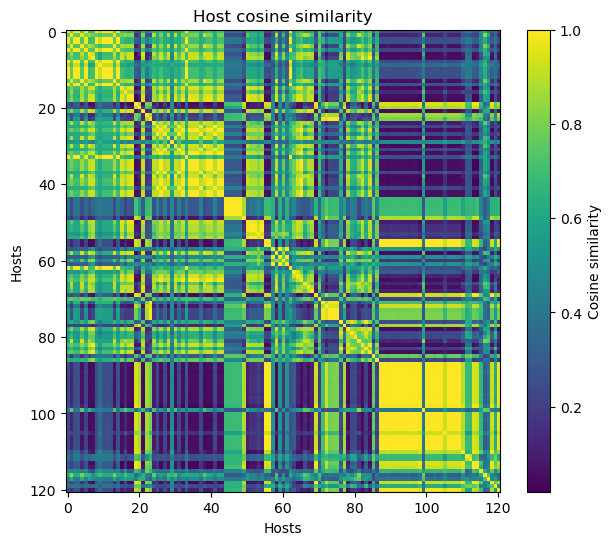

In [17]:
# SIMILARITY MATRICES PLOTS DEPENDING ON SELECTED TRAIINNG MODEL
# (host and/or phage similarity matrices)

# host similarity matrix visualization
if SETTING == "host_unseen":
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(host_sim_df.to_numpy(), aspect="auto")
    ax.set(title="Host cosine similarity", xlabel="Hosts", ylabel="Hosts")
    fig.colorbar(im, ax=ax, label="Cosine similarity")

# phage similarity matrix visualization
elif SETTING == "phage_unseen":
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(phage_sim_df.to_numpy(), aspect="auto")
    ax.set(title="Phage cosine similarity", xlabel="Phages", ylabel="Phages")
    fig.colorbar(im, ax=ax, label="Cosine similarity")

# both phage and host similarity matrix visualization
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True)

    im1 = axes[0].imshow(host_sim_df.to_numpy(), aspect="auto")
    axes[0].set(title="Host cosine similarity", xlabel="Hosts", ylabel="Hosts")
    fig.colorbar(im1, ax=axes[0], label="Cosine similarity")

    im2 = axes[1].imshow(phage_sim_df.to_numpy(), aspect="auto")
    axes[1].set(title="Phage cosine similarity", xlabel="Phages", ylabel="Phages")
    fig.colorbar(im2, ax=axes[1], label="Cosine similarity")

fig.savefig(FIG_DIR / f"{SETTING}_similarity_heatmap.png", dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(FIG_DIR / f"{SETTING}_similarity_heatmap.pdf", bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

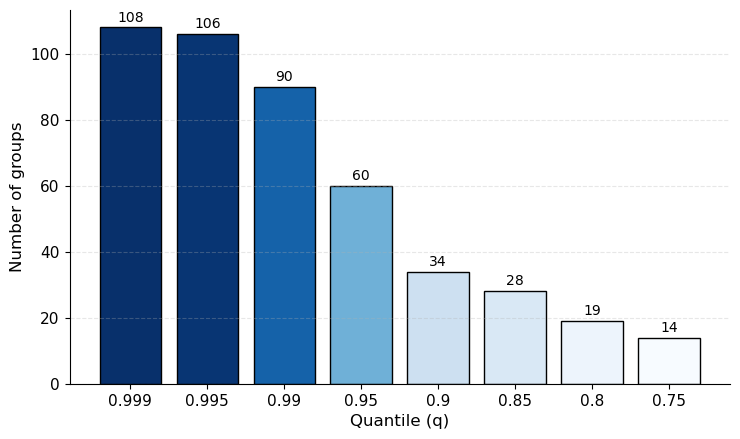

In [18]:
# visualization of the number of similarity-defined host and/or phage groups across similarity quantiles

import matplotlib.cm as cm
import matplotlib.colors as mcolors

qs = [float(q) for q in Q_LIST]
x = np.arange(len(qs))
labels = [f"{q:.3f}".rstrip("0").rstrip(".") for q in qs]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
if SETTING == "host_unseen":
    values = [len(host_groups_by_q[q]) for q in qs]
elif SETTING == "phage_unseen":
    values = [len(phage_groups_by_q[q]) for q in qs]
else:
    values = [len(host_groups_by_q[q]) + len(phage_groups_by_q[q]) for q in qs]

colors = cm.Blues(mcolors.Normalize(min(values), max(values))(values))
bars = ax.bar(x, values, color=colors, edgecolor="black", linewidth=1)

for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width()/2, v + 1, str(v), ha="center", va="bottom", fontsize=10)

ax.set_xticks(x, labels)
ax.set_xlabel("Quantile (q)", fontsize=12)
ax.set_ylabel("Number of groups", fontsize=12)
ax.tick_params(axis="both", labelsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / f"{SETTING}_groups_per_q.png", dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(FIG_DIR / f"{SETTING}_groups_per_q.pdf", bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

In [19]:
# HELPER FUNCTIONS
#defineing common train masks, supervised interaction edges and setting-specific LOGOCV folds

def train_mask(all_ids: List[str], heldout_ids: List[str]) -> np.ndarray:
    heldout = set(heldout_ids)
    return np.array([item not in heldout for item in all_ids], dtype=bool)

def supervision_edges(POSmask: np.ndarray, NEGmask: np.ndarray, train_host_mask: np.ndarray, train_phage_mask: np.ndarray):
    train_pair_mask = train_host_mask[:, None] & train_phage_mask[None, :]
    pos_h, pos_p = np.where(POSmask & train_pair_mask)
    neg_h, neg_p = np.where(NEGmask & train_pair_mask)

    pos_edges = np.stack([pos_p, pos_h], axis=0).astype(np.int64)
    neg_edges = np.stack([neg_p, neg_h], axis=0).astype(np.int64)

    edge_index = np.concatenate([pos_edges, neg_edges], axis=1)

    labels = np.concatenate([
        np.ones(pos_edges.shape[1], dtype=np.float32),
        np.zeros(neg_edges.shape[1], dtype=np.float32),
    ])

    return edge_index, labels, int(pos_edges.shape[1]), int(neg_edges.shape[1])

def make_observed_block_folds(host_groups, phage_groups):
    h2i = {host: i for i, host in enumerate(hosts)}
    p2i = {phage: i for i, phage in enumerate(phages)}

    selected_folds = []
    all_blocks = list(product(range(len(host_groups)), range(len(phage_groups))))

    for host_group_idx, phage_group_idx in all_blocks:
        host_group = host_groups[host_group_idx]
        phage_group = phage_groups[phage_group_idx]

        host_idx = np.array([h2i[host] for host in host_group], dtype=np.int64)
        phage_idx = np.array([p2i[phage] for phage in phage_group], dtype=np.int64)

        if int(OBS[np.ix_(host_idx, phage_idx)].sum()) > 0:
            selected_folds.append({
                "test_hosts": host_group,
                "test_phages": phage_group,
            })

    return selected_folds, len(all_blocks)

def make_folds(q: float):
    if SETTING == "host_unseen":
        folds = [{"test_hosts": group, "test_phages": []} for group in host_groups_by_q[q]]
        return folds, len(folds)

    if SETTING == "phage_unseen":
        folds = [{"test_hosts": [], "test_phages": group} for group in phage_groups_by_q[q]]
        return folds, len(folds)

    return make_observed_block_folds(host_groups_by_q[q], phage_groups_by_q[q])

In [20]:
# Building the train/evaluation graphs and supervision for one LOGOCV fold

def prepare_fold(q: float, fold: Dict[str, List[str]]):
    test_hosts = fold["test_hosts"]
    test_phages = fold["test_phages"]

    h2i = {h: i for i, h in enumerate(hosts)}
    p2i = {p: i for i, p in enumerate(phages)}

    test_host_idx = np.array([h2i[h] for h in test_hosts], dtype=np.int64)
    test_phage_idx = np.array([p2i[p] for p in test_phages], dtype=np.int64)

    train_host_mask = train_mask(hosts, test_hosts)
    train_phage_mask = train_mask(phages, test_phages)

    # Standardizing on the training entities only
    phage_scaler = StandardScaler().fit(X_phage[train_phage_mask])
    host_scaler = StandardScaler().fit(X_host[train_host_mask])
    Xp = phage_scaler.transform(X_phage).astype(np.float32)
    Xh = host_scaler.transform(X_host).astype(np.float32)

    all_phages = np.ones(len(phages), dtype=bool)
    all_hosts = np.ones(len(hosts), dtype=bool)

    # Training graphs
    train_phage_edges = same_type_knn_edges(Xp, K_PHAGE_PHAGE, source_mask=train_phage_mask, target_mask=train_phage_mask)
    train_host_edges = same_type_knn_edges(Xh, K_HOST_HOST, source_mask=train_host_mask, target_mask=train_host_mask)
    # Evaluation graphs
    eval_phage_edges = same_type_knn_edges(Xp, K_PHAGE_PHAGE, source_mask=train_phage_mask if RECEIVE_ONLY_TEST_PHAGES else all_phages, target_mask=all_phages)
    eval_host_edges = same_type_knn_edges(Xh, K_HOST_HOST, source_mask=train_host_mask if RECEIVE_ONLY_TEST_HOSTS else all_hosts, target_mask=all_hosts)

    phage_x = torch.from_numpy(Xp).to(device)
    host_x = torch.from_numpy(Xh).to(device)

    # heterodata objects
    train_data = build_heterodata(
        phage_x,
        host_x,
        torch.from_numpy(train_phage_edges).long().to(device),
        torch.from_numpy(train_host_edges).long().to(device),
    )

    eval_data = build_heterodata(
        phage_x,
        host_x,
        torch.from_numpy(eval_phage_edges).long().to(device),
        torch.from_numpy(eval_host_edges).long().to(device),
    )

    edge_index_np, labels_np, n_pos, n_neg = supervision_edges(POSITIVE_MASK, NEGATIVE_MASK, train_host_mask, train_phage_mask)
    if n_pos == 0:
        return None

    return {
        "train_data": train_data,
        "eval_data": eval_data,
        "edge_index": torch.from_numpy(edge_index_np).long().to(device),
        "labels": torch.from_numpy(labels_np).to(device),
        "n_pos": n_pos,
        "n_neg": n_neg,
        "test_host_idx": test_host_idx,
        "test_phage_idx": test_phage_idx,
        "train_phage_edges": train_phage_edges,
        "train_host_edges": train_host_edges,
        "eval_phage_edges": eval_phage_edges,
        "eval_host_edges": eval_host_edges,
    }

In [21]:
# Preparing one representative LOGOCV fold for graph visualization

VIS_Q = 0.90
vis_folds, _ = make_folds(VIS_Q)

VIS_FOLD_IDX = 0
vis_fold = vis_folds[VIS_FOLD_IDX]
vis_data = prepare_fold(VIS_Q, vis_fold)

print(f"Setting: {SETTING}")
print(f"q: {VIS_Q:.3f}")
print(f"Fold: {VIS_FOLD_IDX}")
print(f"Held-out hosts: {len(vis_fold['test_hosts'])}")
print(f"Held-out phages: {len(vis_fold['test_phages'])}")
print(f"Training positives: {vis_data['n_pos']}")
print(f"Training negatives: {vis_data['n_neg']}")

vis_data["train_data"]

Setting: host_unseen
q: 0.900
Fold: 0
Held-out hosts: 29
Held-out phages: 0
Training positives: 1578
Training negatives: 5230


HeteroData(
  phage={ x=[74, 1152] },
  host={ x=[121, 1152] },
  (phage, similar_to, phage)={ edge_index=[2, 740] },
  (host, similar_to, host)={ edge_index=[2, 920] }
)

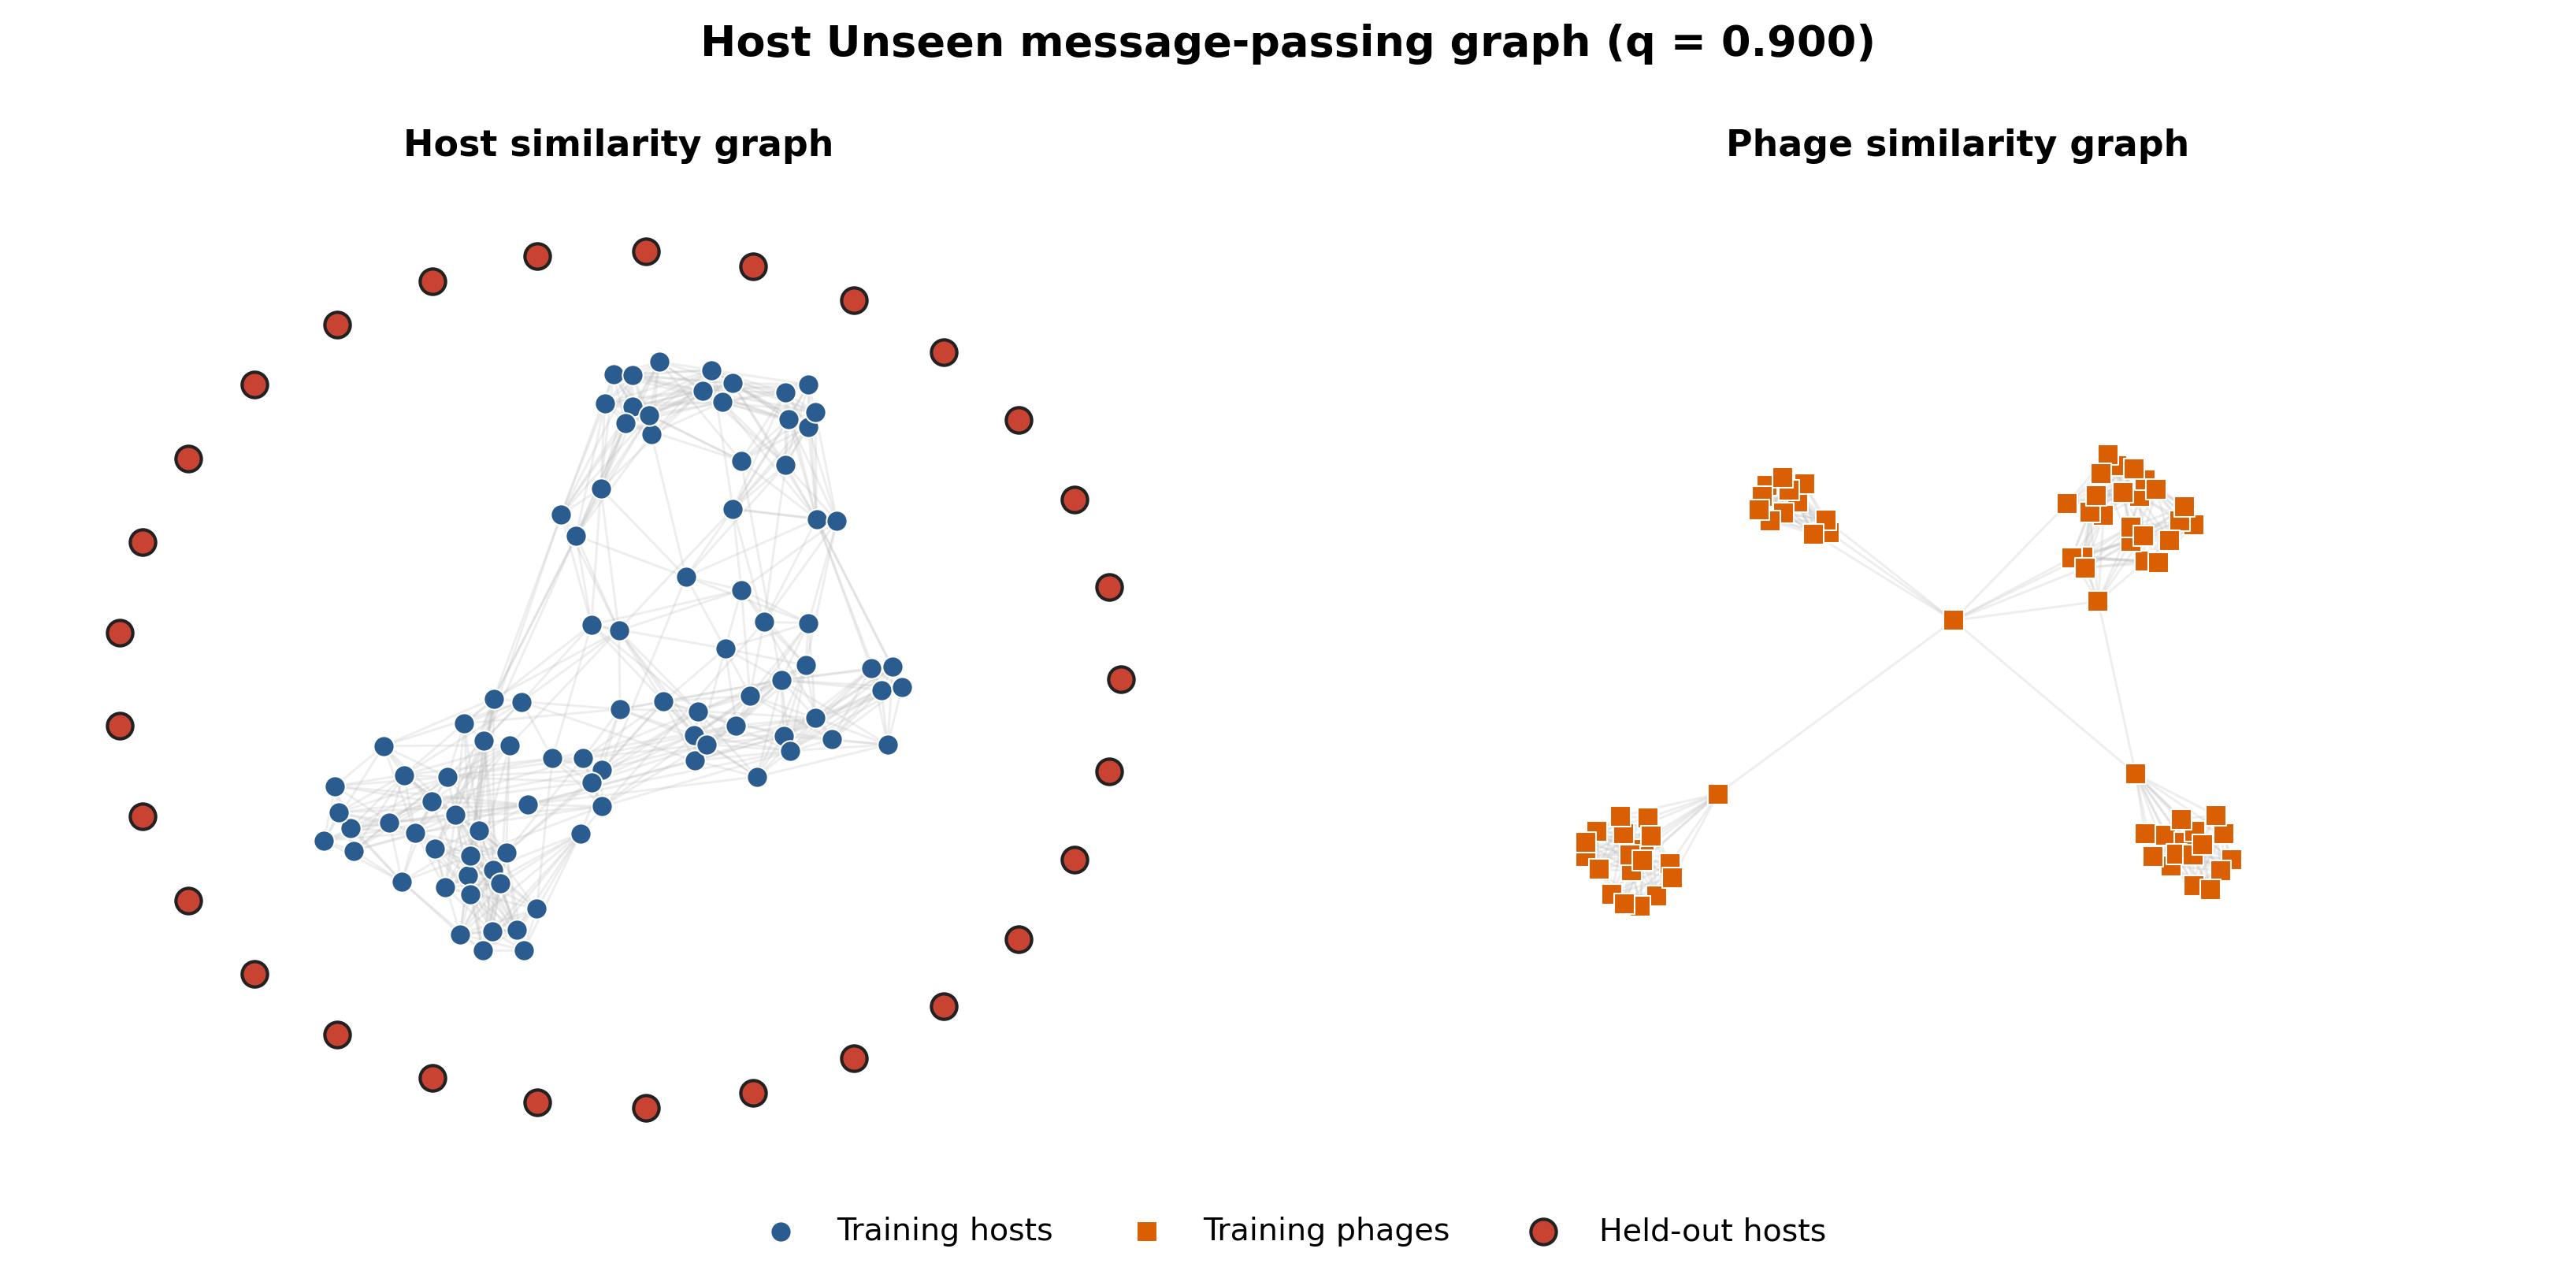

In [22]:
import networkx as nx

# Graph Construction
G = nx.Graph()
test_hosts, test_phages = set(vis_fold["test_hosts"]), set(vis_fold["test_phages"])

G.add_nodes_from([(f"H_{i}", {"type": "host", "heldout": h in test_hosts}) for i, h in enumerate(hosts)])
G.add_nodes_from([(f"P_{i}", {"type": "phage", "heldout": p in test_phages}) for i, p in enumerate(phages)])
G.add_edges_from([(f"H_{int(s)}", f"H_{int(t)}") for s, t in vis_data["train_host_edges"].T])
G.add_edges_from([(f"P_{int(s)}", f"P_{int(t)}") for s, t in vis_data["train_phage_edges"].T])

#  layout helper function
def get_layout(sub_nodes, center_x, seed):
    sub = G.subgraph(sub_nodes)
    tr = [n for n, d in sub.nodes(data=True) if not d["heldout"]]
    ho = [n for n, d in sub.nodes(data=True) if d["heldout"]]

    pos = {}
    if tr:
        tr_pos = nx.spring_layout(sub.subgraph(tr), seed=seed, k=0.55 / np.sqrt(len(tr)), iterations=150)
        pos.update({n: (x + center_x, y) for n, (x, y) in tr_pos.items()})

    if ho:
        angles = np.linspace(0, 2 * np.pi, len(ho), endpoint=False)
        pos.update({n: (center_x + 1.35 * np.cos(a), 1.35 * np.sin(a)) for n, a in zip(ho, angles)})

    return pos, tr, ho

pos_h, train_hosts, test_hosts_nodes = get_layout([n for n, d in G.nodes(data=True) if d["type"] == "host"], -1.8, SEED)
pos_p, train_phages, test_phages_nodes = get_layout([n for n, d in G.nodes(data=True) if d["type"] == "phage"], 1.8, SEED + 1)
pos = {**pos_h, **pos_p}

# Rendering
fig, ax = plt.subplots(figsize=(11, 5.5), dpi=300)
nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#BDBDBD", alpha=0.25, width=0.7)
def draw_group(nodes, shape, color, sz, edge, lw, lbl):
    if nodes:
        nx.draw_networkx_nodes(
            G, pos, ax=ax, nodelist=nodes, node_shape=shape, node_color=color,
            node_size=sz, edgecolors=edge, linewidths=lw, label=lbl
        )

draw_group(train_hosts, "o", "#2B5C8F", 40, "white", 0.5, "Training hosts")
draw_group(train_phages, "s", "#D95F02", 40, "white", 0.5, "Training phages")
draw_group(test_hosts_nodes, "o", "#C84332", 60, "#222222", 1.0, "Held-out hosts")
draw_group(test_phages_nodes, "s", "#C84332", 60, "#222222", 1.0, "Held-out phages")

# Annotations and Styling
ax.text(-1.8, 1.65, "Host similarity graph", ha="center", fontsize=11, fontweight="bold")
ax.text(1.8, 1.65, "Phage similarity graph", ha="center", fontsize=11, fontweight="bold")
ax.set_title(
    f"{SETTING.replace('_', ' ').title()} message-passing graph (q = {VIS_Q:.3f})",
    fontsize=13, fontweight="bold", pad=16
)

ax.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, -0.08), ncol=4, fontsize=9.5)
ax.set_xlim(-3.4, 3.4)
ax.set_ylim(-1.6, 1.8)
ax.axis("off")

plt.tight_layout()
fig.savefig(FIG_DIR / f"{SETTING}_message_passing_graph.png", dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(FIG_DIR / f"{SETTING}_message_passing_graph.pdf", bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

In [23]:
# training the GNN for one LOGOCV fold
def fit_fold_model(fold_data, q: float, fold_idx: int):
    train_data = fold_data["train_data"]
    edge_index = fold_data["edge_index"]
    labels = fold_data["labels"]

    n_pos = fold_data["n_pos"]
    n_neg = fold_data["n_neg"]

    pos_weight = min(float(n_neg) / float(max(1, n_pos)), 10.0)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], device=device))

    model = build_model(train_data)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_CV, eta_min=LR * 0.05)

    model.train()
    for epoch in range(1, EPOCHS_CV + 1):
        optimizer.zero_grad(set_to_none=True)

        if EDGE_LOSS_CHUNK and edge_index.size(1) > EDGE_LOSS_CHUNK:
            z = model.encode(train_data)
            permutation = torch.randperm(edge_index.size(1), device=device)

            total_loss = 0.0
            n_chunks = 0

            for start in range(0, edge_index.size(1), EDGE_LOSS_CHUNK):
                idx = permutation[start:start + EDGE_LOSS_CHUNK]

                logits = model.decode(z, edge_index[:, idx])
                loss = loss_fn(logits, labels[idx])
                loss.backward(retain_graph=start + EDGE_LOSS_CHUNK < edge_index.size(1))
                total_loss += float(loss.item())
                n_chunks += 1

            loss_value = total_loss / n_chunks

        else:
            logits = model(train_data, edge_index)
            loss = loss_fn(logits, labels)
            loss.backward()
            loss_value = float(loss.item())

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        if epoch in (1, EPOCHS_CV) or epoch % 25 == 0:
            print(f"[{SETTING} q={q:.3f} fold={fold_idx:03d}] epoch={epoch:03d} loss={loss_value:.4f} pos={n_pos} neg={n_neg}")

    return model

In [24]:
#evaluating a single trained fold basedon the selected unseen setting
def evaluate_fold(model, fold_data, q: float, fold_idx: int):
    model.eval()
    with torch.no_grad():
        z = model.encode(fold_data["eval_data"])

    test_host_idx = fold_data["test_host_idx"]
    test_phage_idx = fold_data["test_phage_idx"]

    fold_y, fold_s, ranked_queries = [], [], []
    auc_per_query, ap_per_query, positives_per_query = [], [], []

    hit_at_k = {k: [] for k in range(1, MAX_K + 1)}
    precision_at_k = {k: [] for k in range(1, MAX_K + 1)}
    recall_at_k = {k: [] for k in range(1, MAX_K + 1)}

    pair_rows = []
    if SETTING == "host_unseen":
        query_indices = test_host_idx

    elif SETTING == "phage_unseen":
        query_indices = test_phage_idx

    else:
        query_indices = test_host_idx

    for query_idx in query_indices:
        if SETTING == "host_unseen":
            scores = score_all_phages(z, model, int(query_idx), len(phages))

            pos = POSITIVE_MASK[query_idx]
            neg = NEGATIVE_MASK[query_idx]
            obs = pos | neg

            y_obs = pos[obs].astype(np.int32)
            s_obs = scores[obs].astype(np.float32)
            candidate_idx = np.flatnonzero(obs)

            pair_rows.extend([
                (
                    phages[int(p)],
                    hosts[int(query_idx)],
                    int(y),
                    float(s),
                    int(fold_idx),
                    float(host_thr_by_q[q]),
                )
                for p, y, s in zip(candidate_idx, y_obs, s_obs)
            ])

        elif SETTING == "phage_unseen":
            scores = score_all_hosts(z, model, int(query_idx), len(hosts))

            pos = POSITIVE_MASK[:, query_idx]
            neg = NEGATIVE_MASK[:, query_idx]
            obs = pos | neg

            y_obs = pos[obs].astype(np.int32)
            s_obs = scores[obs].astype(np.float32)
            candidate_idx = np.flatnonzero(obs)

            pair_rows.extend([
                (
                    phages[int(query_idx)],
                    hosts[int(h)],
                    int(y),
                    float(s),
                    int(fold_idx),
                    float(phage_thr_by_q[q]),
                )
                for h, y, s in zip(candidate_idx, y_obs, s_obs)
            ])

        else:
            scores = score_all_phages(z, model, int(query_idx), len(phages))

            pos = POSITIVE_MASK[query_idx, test_phage_idx]
            neg = NEGATIVE_MASK[query_idx, test_phage_idx]
            obs = pos | neg

            y_obs = pos[obs].astype(np.int32)
            s_obs = scores[test_phage_idx][obs].astype(np.float32)
            candidate_idx = test_phage_idx[obs]

            pair_rows.extend([
                (
                    phages[int(p)],
                    hosts[int(query_idx)],
                    int(y),
                    float(s),
                    int(fold_idx),
                    float(host_thr_by_q[q]),
                    float(phage_thr_by_q[q]),
                )
                for p, y, s in zip(candidate_idx, y_obs, s_obs)
            ])

        if y_obs.size == 0:
            continue

        fold_y.append(y_obs)
        fold_s.append(s_obs)

        npos = int(y_obs.sum())
        nneg = int(y_obs.size - npos)

        if npos == 0:
            continue

        positives_per_query.append(npos)

        ranked = y_obs[np.argsort(-s_obs)]
        ranked_queries.append(ranked)

        hit, precision, recall = hit_precision_recall_at_k_from_ranked(ranked, npos, MAX_K)
        for k in range(1, MAX_K + 1):
            hit_at_k[k].append(float(hit[k - 1]))
            precision_at_k[k].append(float(precision[k - 1]))
            recall_at_k[k].append(float(recall[k - 1]))

        ap_per_query.append(float(average_precision_score(y_obs, s_obs)))

        if nneg > 0:
            auc_per_query.append(float(roc_auc_score(y_obs, s_obs)))

    if not fold_y:
        return None

    y_fold = np.concatenate(fold_y).astype(np.int32)
    s_fold = np.concatenate(fold_s).astype(np.float32)

    fold_auc = (
        float(roc_auc_score(y_fold, s_fold))
        if np.unique(y_fold).size > 1
        else float("nan")
    )

    fold_ap = (
        float(average_precision_score(y_fold, s_fold))
        if y_fold.sum() > 0
        else float("nan")
    )

    return {
        "y_fold": y_fold,
        "s_fold": s_fold,
        "fold_auc": fold_auc,
        "fold_ap": fold_ap,
        "rqueries": ranked_queries,
        "hit_at_k": hit_at_k,
        "prec_at_k": precision_at_k,
        "rec_at_k": recall_at_k,
        "auc_per_query": auc_per_query,
        "ap_per_query": ap_per_query,
        "n_pos_per_query": positives_per_query,
        "pair_rows": pair_rows,
    }

In [25]:
# running the complete preparation, training and evaluation workflow for one fold
def train_one_fold(q: float, fold_idx: int, fold: Dict[str, List[str]]):
    fold_data = prepare_fold(q, fold)
    if fold_data is None:
        return None

    model = fit_fold_model(fold_data, q, fold_idx)
    return evaluate_fold(model, fold_data, q, fold_idx)

In [26]:
#aggregating fold predictions into pooled classification metrics, ranking curves and q-level summaries
def hitratio_from_ranked_queries(ranked_queries, k):
    if not ranked_queries:
        return float("nan")

    hits = []
    for ranked in ranked_queries:
        ranked = np.asarray(ranked, dtype=np.int32)
        if ranked.size:
            current_k = min(k, ranked.size)
            hits.append(float(ranked[:current_k].sum() > 0))

    return float(np.mean(hits)) if hits else float("nan")


def run_logocv(q: float):
    folds, n_total_folds = make_folds(q)
    n_folds_trained = 0

    print("\n" + "=" * 72)
    print(f"{SETTING.upper()} | q={q:.3f} | evaluated folds={len(folds)} | total folds={n_total_folds}")

    labels, scores, ranked_queries, pair_rows = [], [], [], []
    fold_auc, fold_ap = [], []

    hit_all = {k: [] for k in range(1, MAX_K + 1)}
    precision_all = {k: [] for k in range(1, MAX_K + 1)}
    recall_all = {k: [] for k in range(1, MAX_K + 1)}

    for fold_idx, fold in enumerate(folds):
        result = train_one_fold(q, fold_idx, fold)

        if result is None:
            continue

        n_folds_trained += 1
        pair_rows.extend(result["pair_rows"])

        if result["y_fold"].size:
            labels.append(result["y_fold"])
            scores.append(result["s_fold"])

        if result["rqueries"]:
            ranked_queries.extend(result["rqueries"])

        if np.isfinite(result["fold_auc"]):
            fold_auc.append(result["fold_auc"])

        if np.isfinite(result["fold_ap"]):
            fold_ap.append(result["fold_ap"])

        for k in range(1, MAX_K + 1):
            hit_all[k].extend(result["hit_at_k"][k])
            precision_all[k].extend(result["prec_at_k"][k])
            recall_all[k].extend(result["rec_at_k"][k])

    if labels:
        pooled_labels = np.concatenate(labels).astype(np.int32)
        pooled_scores = np.concatenate(scores).astype(np.float32)

        pooled_auc = (
            float(roc_auc_score(pooled_labels, pooled_scores))
            if np.unique(pooled_labels).size > 1
            else float("nan")
        )

        pooled_ap = (
            float(average_precision_score(pooled_labels, pooled_scores))
            if pooled_labels.sum() > 0
            else float("nan")
        )

    else:
        pooled_labels = np.array([], dtype=np.int32)
        pooled_scores = np.array([], dtype=np.float32)
        pooled_auc = float("nan")
        pooled_ap = float("nan")

    hit_curve = np.array([hitratio_from_ranked_queries(ranked_queries, k) for k in range(1, MAX_K + 1)], dtype=np.float32)
    mean_hit_curve = np.array([np.mean(hit_all[k]) if hit_all[k] else np.nan for k in range(1, MAX_K + 1)], dtype=np.float32)
    mean_precision_curve = np.array([np.mean(precision_all[k]) if precision_all[k] else np.nan for k in range(1, MAX_K + 1)], dtype=np.float32)
    mean_recall_curve = np.array([np.mean(recall_all[k]) if recall_all[k] else np.nan for k in range(1, MAX_K + 1)], dtype=np.float32)
    print(f"Completed q={q:.3f} | folds={n_folds_trained}/{len(folds)} | pairs={len(pooled_labels)} | positives={int(pooled_labels.sum())}")

    return {
        "pooled_labels": pooled_labels,
        "pooled_scores": pooled_scores,
        "pooled_auc": pooled_auc,
        "pooled_ap": pooled_ap,
        "macro_auc_mean": float(np.mean(fold_auc)) if fold_auc else float("nan"),
        "macro_auc_std": float(np.std(fold_auc)) if fold_auc else float("nan"),
        "macro_ap_mean": float(np.mean(fold_ap)) if fold_ap else float("nan"),
        "macro_ap_std": float(np.std(fold_ap)) if fold_ap else float("nan"),
        "rqueries": ranked_queries,
        "hit_curve": hit_curve,
        "mean_hit_curve": mean_hit_curve,
        "mean_prec_curve": mean_precision_curve,
        "mean_rec_curve": mean_recall_curve,
        "hit_at_k": hit_all,
        "prec_at_k": precision_all,
        "rec_at_k": recall_all,
        "n_folds_trained": n_folds_trained,
        "n_folds_total": n_total_folds,
        "pair_rows": pair_rows,
    }


def best_q_by_ap(all_results):
    candidates = []
    for q, result in all_results.items():
        pooled_ap = float(result["pooled_ap"])
        hit10_values = result["hit_at_k"][10]
        hit10 = float(np.mean(hit10_values)) if hit10_values else float("nan")

        if np.isfinite(pooled_ap):
            candidates.append((pooled_ap, hit10 if np.isfinite(hit10) else -np.inf, float(q)))

    if not candidates:
        return float("nan")

    candidates.sort(key=lambda x: (x[0], x[1]), reverse=True)
    return candidates[0][2]

In [27]:
# running LOGOCV across all similarity quantiles
# and saving each q-level result for downstream analysis

all_results: Dict[float, Dict[str, Any]] = {}
for q in Q_LIST:
    q = float(q)
    summary = run_logocv(q)
    all_results[q] = summary

    print(f"[DONE q={q:.3f}] AUROC={summary['pooled_auc']:.3f} AUPRC={summary['pooled_ap']:.3f}")

    payload = {
        "setting": SETTING,
        "q": q,
        "pooled_labels": summary["pooled_labels"],
        "pooled_scores": summary["pooled_scores"],
        "pooled_auc": summary["pooled_auc"],
        "pooled_ap": summary["pooled_ap"],
        "hit_curve": summary["hit_curve"],
        "mean_hit_curve": summary["mean_hit_curve"],
        "mean_prec_curve": summary["mean_prec_curve"],
        "mean_rec_curve": summary["mean_rec_curve"],
        "n_folds_trained": summary["n_folds_trained"],
        "n_folds_total": summary["n_folds_total"],
        "model_kwargs": MODEL_KWARGS,
        "message_passing_graph": "within_type_cosine_knn",
        "k_phage_phage": K_PHAGE_PHAGE,
        "k_host_host": K_HOST_HOST,
        "receive_only_test_hosts": RECEIVE_ONLY_TEST_HOSTS,
        "receive_only_test_phages": RECEIVE_ONLY_TEST_PHAGES,
        "pair_rows": summary["pair_rows"],
    }

    if SETTING == "host_unseen":
        payload.update({
            "thr": host_thr_by_q[q],
            "thr_by_q": host_thr_by_q,
        })
        filename = f"logocv_results_{MODEL_NAME}_q_{q:.3f}.pickle"

    elif SETTING == "phage_unseen":
        payload.update({
            "thr": phage_thr_by_q[q],
            "thr_by_q": phage_thr_by_q,
        })
        filename = f"logocv_results_{MODEL_NAME}_q_{q:.3f}.pickle"

    else:
        payload.update({
            "host_q": q,
            "phage_q": q,
            "host_thr": host_thr_by_q[q],
            "phage_thr": phage_thr_by_q[q],
            "host_thr_by_q": host_thr_by_q,
            "phage_thr_by_q": phage_thr_by_q,
        })

        filename = f"logocv_both_unseen_results_{MODEL_NAME}_q_{q:.3f}.pickle"

    with open(RAW_DIR / filename, "wb") as file:
        pickle.dump(payload, file)

    print("Saved:", RAW_DIR / filename)
    cleanup_cuda()


HOST_UNSEEN | q=0.999 | evaluated folds=108 | total folds=108
[host_unseen q=0.999 fold=000] epoch=001 loss=1.1201 pos=1730 neg=6632
[host_unseen q=0.999 fold=000] epoch=025 loss=0.5182 pos=1730 neg=6632
[host_unseen q=0.999 fold=000] epoch=050 loss=0.4243 pos=1730 neg=6632
[host_unseen q=0.999 fold=000] epoch=075 loss=0.3854 pos=1730 neg=6632
[host_unseen q=0.999 fold=000] epoch=100 loss=0.3512 pos=1730 neg=6632
[host_unseen q=0.999 fold=000] epoch=125 loss=0.3266 pos=1730 neg=6632
[host_unseen q=0.999 fold=000] epoch=150 loss=0.3172 pos=1730 neg=6632
[host_unseen q=0.999 fold=000] epoch=175 loss=0.3044 pos=1730 neg=6632
[host_unseen q=0.999 fold=000] epoch=200 loss=0.2928 pos=1730 neg=6632
[host_unseen q=0.999 fold=001] epoch=001 loss=1.1128 pos=1791 neg=6941
[host_unseen q=0.999 fold=001] epoch=025 loss=0.4905 pos=1791 neg=6941
[host_unseen q=0.999 fold=001] epoch=050 loss=0.4327 pos=1791 neg=6941
[host_unseen q=0.999 fold=001] epoch=075 loss=0.3691 pos=1791 neg=6941
[host_unseen q

In [28]:
# saving main LOGOCV performance statistics across all similarity quantiles
summary_rows = []
for q in sorted(all_results, reverse=True):
    result = all_results[q]
    row = {
        "setting": SETTING,
        "q": q,
        "pooled_auc": result["pooled_auc"],
        "pooled_ap": result["pooled_ap"],
        "macro_auc_mean": result["macro_auc_mean"],
        "macro_auc_std": result["macro_auc_std"],
        "macro_ap_mean": result["macro_ap_mean"],
        "macro_ap_std": result["macro_ap_std"],
        "hit@10_mean": float(np.mean(result["hit_at_k"][10])) if result["hit_at_k"][10] else np.nan,
        "precision@10_mean": float(np.mean(result["prec_at_k"][10])) if result["prec_at_k"][10] else np.nan,
        "recall@10_mean": float(np.mean(result["rec_at_k"][10])) if result["rec_at_k"][10] else np.nan,
        "n_folds_trained": result["n_folds_trained"],
        "n_folds_total": result["n_folds_total"],
    }

    if SETTING == "host_unseen":
        row["threshold"] = host_thr_by_q[q]

    elif SETTING == "phage_unseen":
        row["threshold"] = phage_thr_by_q[q]

    else:
        row["host_threshold"] = host_thr_by_q[q]
        row["phage_threshold"] = phage_thr_by_q[q]

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_file = (
    FIG_DIR / f"logocv_both_unseen_summary_{MODEL_NAME}.csv"
    if SETTING == "both_unseen"
    else FIG_DIR / f"logocv_summary_{MODEL_NAME}.csv"
)

summary_df.to_csv(summary_file, index=False)
print("Summary file saved:", summary_file)

Summary file saved: /home/biffon/GNN_models/PhageHost_GNN/CV_training_and_results/ESMC/LOGOCV_within_type_cosineSim_outputs_PhageUnseen/figures/logocv_summary_ESMC.csv


In [29]:
summary_df

,setting,q,pooled_auc,pooled_ap,macro_auc_mean,macro_auc_std,macro_ap_mean,macro_ap_std,hit@10_mean,precision@10_mean,recall@10_mean,n_folds_trained,n_folds_total,threshold
0,host_unseen,0.999,0.908180,0.765314,0.851070,0.201955,0.633602,0.356110,0.867769,0.544628,0.483274,108,108,1.000000
1,host_unseen,0.995,0.905576,0.757882,0.853374,0.200892,0.634674,0.364264,0.867769,0.547934,0.493359,106,106,1.000000
2,host_unseen,0.990,0.901599,0.757801,0.833889,0.208162,0.595176,0.355342,0.876033,0.525620,0.487735,90,90,0.999890
3,host_unseen,0.950,0.896059,0.746249,0.782693,0.230543,0.505783,0.348191,0.884298,0.511570,0.457495,60,60,0.992314
4,host_unseen,0.900,0.886707,0.746525,0.780931,0.194766,0.492440,0.347775,0.851240,0.490083,0.426012,34,34,0.922039
5,host_unseen,0.850,0.809784,0.613352,0.736161,0.223785,0.407353,0.356735,0.752066,0.369421,0.308208,28,28,0.883867
6,host_unseen,0.800,0.866619,0.699417,0.732111,0.226417,0.444400,0.352028,0.859504,0.488430,0.443366,19,19,0.807818
7,host_unseen,0.750,0.867410,0.683592,0.784643,0.232208,0.515180,0.337811,0.801653,0.504959,0.428923,14,14,0.761363


In [30]:
# Selecting the best similarity quantile using pooled AUPRC and Hit@10 as the tie-breaker

best_q = best_q_by_ap(all_results)
if not np.isfinite(best_q):
    raise RuntimeError("No valid quantile was obtained from LOGOCV.")

best_q = float(best_q)
best_result = all_results[best_q]
best_hit10 = (
    float(np.mean(best_result["hit_at_k"][10]))
    if best_result["hit_at_k"][10]
    else float("nan")
)

print(f"Best q performance: {best_q:.3f}; AUROC: {best_result['pooled_auc']:.4f}; AUPRC: {best_result['pooled_ap']:.4f}; Hit@10: {best_hit10:.4f}")

Best q performance: 0.999; AUROC: 0.9082; AUPRC: 0.7653; Hit@10: 0.8678


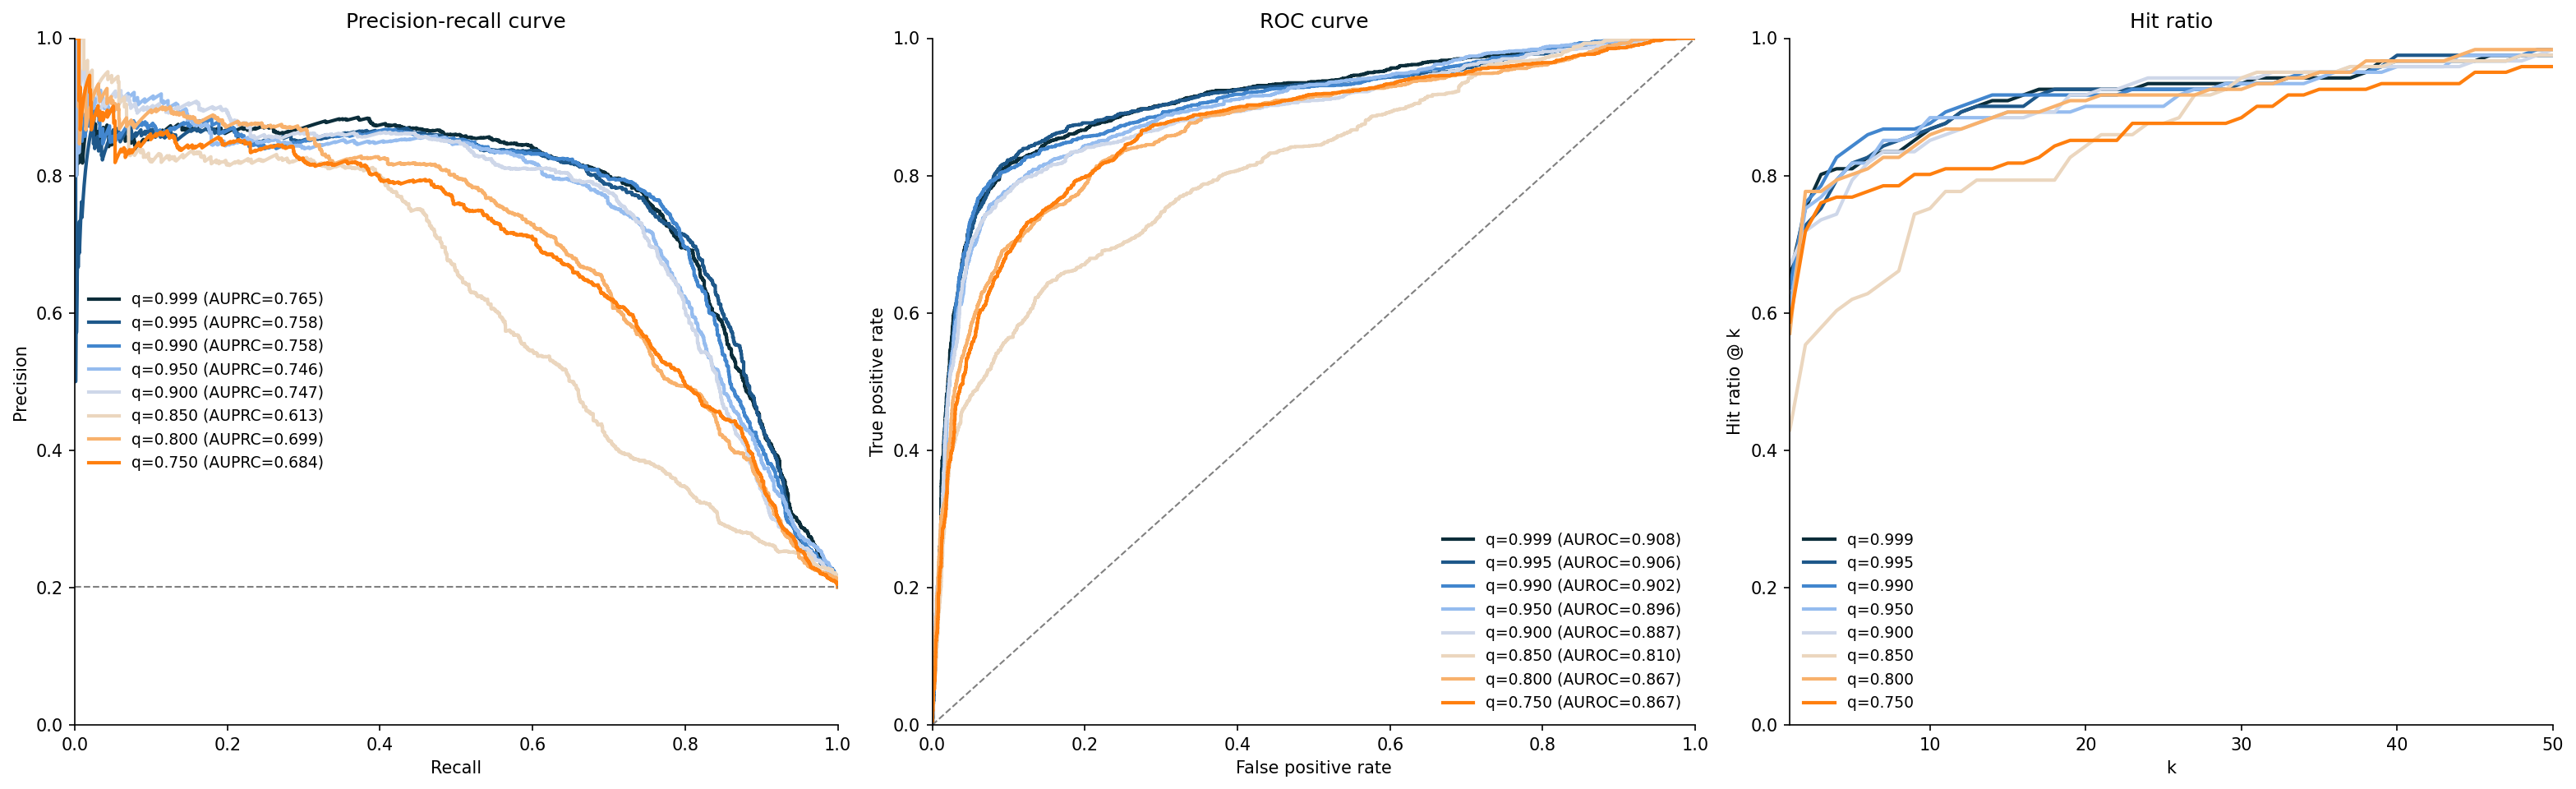

In [31]:
#plotting AUPRC, AUROC and HR@K across all similarity quantiles
from matplotlib.colors import LinearSegmentedColormap

qs = sorted(all_results, reverse=True)
cmap = LinearSegmentedColormap.from_list(
    "blue_orange",
    ["#0B2D3A", "#2D78C6", "#BFD7FF", "#F2D6B3", "#FF7F0E"],
    N=max(2, len(qs)),
)
colors = [cmap(x) for x in np.linspace(0.05, 0.95, len(qs))]

fig, axes = plt.subplots(1, 3, figsize=(21, 6.5), dpi=150)
ax_pr, ax_roc, ax_hit = axes
for q, color in zip(qs, colors):
    result = all_results[q]

    y_true = np.asarray(result["pooled_labels"], dtype=int)
    y_score = np.asarray(result["pooled_scores"], dtype=float)

    # precision-recall curve
    if y_true.size and y_score.size and y_true.sum() > 0:
        precision, recall, _ = precision_recall_curve(y_true, y_score)
        ax_pr.plot(recall, precision, color=color, linewidth=2, label=f"q={q:.3f} (AUPRC={result['pooled_ap']:.3f})")

    # ROC curve
    if y_true.size and y_score.size and np.unique(y_true).size > 1:
        fpr, tpr, _ = roc_curve(y_true, y_score)
        ax_roc.plot(fpr, tpr, color=color, linewidth=2, label=f"q={q:.3f} (AUROC={result['pooled_auc']:.3f})")

    # Hit ratio curve
    hit_values = [
        np.mean(result["hit_at_k"][k]) if result["hit_at_k"][k] else np.nan
        for k in range(1, MAX_K + 1)
    ]

    ax_hit.plot(
        range(1, MAX_K + 1),
        hit_values,
        color=color,
        linewidth=2,
        label=f"q={q:.3f}",
    )

# random baselines
best_y = np.asarray(best_result["pooled_labels"], dtype=int)
if best_y.size:
    ax_pr.axhline(best_y.mean(), color="gray", linestyle="--", linewidth=1)

ax_roc.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1)

# axes
ax_pr.set(xlim=(0, 1), ylim=(0, 1), xlabel="Recall", ylabel="Precision", title="Precision-recall curve")
ax_roc.set(xlim=(0, 1), ylim=(0, 1), xlabel="False positive rate", ylabel="True positive rate", title="ROC curve")
ax_hit.set(xlim=(1, MAX_K), ylim=(0, 1), xlabel="k", ylabel="Hit ratio @ k", title="Hit ratio")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, fontsize=9)

fig.tight_layout()
fig.savefig(FIG_DIR / f"{SETTING}_AUPRC_AUROC_HRatK.png", dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(FIG_DIR / f"{SETTING}_AUPRC_AUROC_HRatK.pdf", bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

In [32]:
# defining final full-data training to generates inference models

def train_final_model(q: float, save_dir: Path):
    save_dir.mkdir(parents=True, exist_ok=True)

    # standardizing all entities to a uniform scale
    phage_scaler = StandardScaler().fit(X_phage)
    host_scaler = StandardScaler().fit(X_host)
    Xp = phage_scaler.transform(X_phage).astype(np.float32)
    Xh = host_scaler.transform(X_host).astype(np.float32)

    # full message-passing graphs
    phage_edges = same_type_knn_edges(Xp, K_PHAGE_PHAGE)
    host_edges = same_type_knn_edges(Xh, K_HOST_HOST)

    # heterodata object
    data = build_heterodata(
        torch.from_numpy(Xp).to(device),
        torch.from_numpy(Xh).to(device),
        torch.from_numpy(phage_edges).long().to(device),
        torch.from_numpy(host_edges).long().to(device),
    )

    # all observed interactions to provide final supervision
    all_hosts = np.ones(len(hosts), dtype=bool)
    all_phages = np.ones(len(phages), dtype=bool)

    edge_index_np, labels_np, n_pos, n_neg = supervision_edges(
        POSITIVE_MASK,
        NEGATIVE_MASK,
        all_hosts,
        all_phages,
    )

    edge_index = torch.from_numpy(edge_index_np).long().to(device)
    labels = torch.from_numpy(labels_np).to(device)

    pos_weight = min(float(n_neg) / float(max(1, n_pos)), 10.0)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], device=device))
    model = build_model(data)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS_FINAL,
        eta_min=LR * 0.05,
    )

    loss_history = []

    print(f"Final model training | {SETTING} | q={q:.3f} | pos={n_pos} neg={n_neg} pos_weight={pos_weight:.2f}")

    model.train()
    for epoch in range(1, EPOCHS_FINAL + 1):
        optimizer.zero_grad(set_to_none=True)
        logits = model(data, edge_index)
        loss = loss_fn(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        loss_history.append(float(loss.item()))
        if epoch in (1, EPOCHS_FINAL) or epoch % 25 == 0:
            print(f"[FINAL q={q:.3f}] epoch={epoch:03d} loss={loss.item():.4f} lr={optimizer.param_groups[0]['lr']:.2e}")

    return {
        "model": model,
        "phage_scaler": phage_scaler,
        "host_scaler": host_scaler,
        "loss_history": loss_history,
        "n_pos": n_pos,
        "n_neg": n_neg,
        "pos_weight": pos_weight,
        "n_phage_edges": phage_edges.shape[1],
        "n_host_edges": host_edges.shape[1],
    }

In [33]:
#saving the trained model, feature scalers, training loss and metadata for one quantile

def save_final_model(result, q: float, save_dir: Path):
    model = result["model"]
    phage_scaler = result["phage_scaler"]
    host_scaler = result["host_scaler"]
    loss_history = result["loss_history"]

    tag = (
        f"hostq_{q:.3f}_phageq_{q:.3f}"
        if SETTING == "both_unseen"
        else f"q_{q:.3f}"
    )

    # training loss
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(
        range(1, len(loss_history) + 1),
        loss_history,
        linewidth=2,
    )

    ax.set(xlabel="Epoch", ylabel="Training loss", title=f"Final training loss ({MODEL_NAME}, q={q:.3f})")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()
    fig.savefig(save_dir / f"final_training_loss_{MODEL_NAME}_{tag}.png", dpi=600, bbox_inches="tight", facecolor="white")
    fig.savefig(save_dir / f"final_training_loss_{MODEL_NAME}_{tag}.pdf", bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)

    # model weights
    torch.save(model.state_dict(), save_dir / f"final_model_{MODEL_NAME}_{tag}.pt")

    # feature scalers
    np.savez(
        save_dir / f"final_scalers_{MODEL_NAME}_{tag}.npz",
        ph_mean=phage_scaler.mean_,
        ph_scale=phage_scaler.scale_,
        ho_mean=host_scaler.mean_,
        ho_scale=host_scaler.scale_,
    )

    # Metadata
    metadata = {
        "model": MODEL_NAME,
        "setting": SETTING,
        "q": float(q),
        "epochs": EPOCHS_FINAL,
        "learning_rate": LR,
        "weight_decay": WD,
        "k_phage_phage": K_PHAGE_PHAGE,
        "k_host_host": K_HOST_HOST,
        "n_phage_phage_edges": int(result["n_phage_edges"]),
        "n_host_host_edges": int(result["n_host_edges"]),
        "n_hosts": len(hosts),
        "n_phages": len(phages),
        "n_pos": int(result["n_pos"]),
        "n_neg": int(result["n_neg"]),
        "pos_weight": float(result["pos_weight"]),
        "model_kwargs": MODEL_KWARGS,
    }

    if SETTING in {"host_unseen", "both_unseen"}:
        metadata["host_q"] = float(q)
        metadata["host_threshold"] = float(host_thr_by_q[q])

    if SETTING in {"phage_unseen", "both_unseen"}:
        metadata["phage_q"] = float(q)
        metadata["phage_threshold"] = float(phage_thr_by_q[q])

    metadata_path = save_dir / f"final_meta_{MODEL_NAME}_{tag}.json"
    metadata_path.write_text(json.dumps(metadata, indent=2))


Training final model: ESMC, q=0.999
Host threshold: 1.000000
Best q selected by LOGOCV.
Final model training | host_unseen | q=0.999 | pos=1800 neg=7154 pos_weight=3.97
[FINAL q=0.999] epoch=001 loss=1.1290 lr=1.00e-03
[FINAL q=0.999] epoch=025 loss=0.5003 lr=9.94e-04
[FINAL q=0.999] epoch=050 loss=0.4124 lr=9.77e-04
[FINAL q=0.999] epoch=075 loss=0.3835 lr=9.48e-04
[FINAL q=0.999] epoch=100 loss=0.3413 lr=9.09e-04
[FINAL q=0.999] epoch=125 loss=0.3147 lr=8.61e-04
[FINAL q=0.999] epoch=150 loss=0.2984 lr=8.04e-04
[FINAL q=0.999] epoch=175 loss=0.2915 lr=7.41e-04
[FINAL q=0.999] epoch=200 loss=0.2711 lr=6.72e-04
[FINAL q=0.999] epoch=225 loss=0.2602 lr=5.99e-04
[FINAL q=0.999] epoch=250 loss=0.2511 lr=5.25e-04
[FINAL q=0.999] epoch=275 loss=0.2396 lr=4.51e-04
[FINAL q=0.999] epoch=300 loss=0.2446 lr=3.78e-04
[FINAL q=0.999] epoch=325 loss=0.2267 lr=3.09e-04
[FINAL q=0.999] epoch=350 loss=0.2244 lr=2.46e-04
[FINAL q=0.999] epoch=375 loss=0.2074 lr=1.89e-04
[FINAL q=0.999] epoch=400 loss

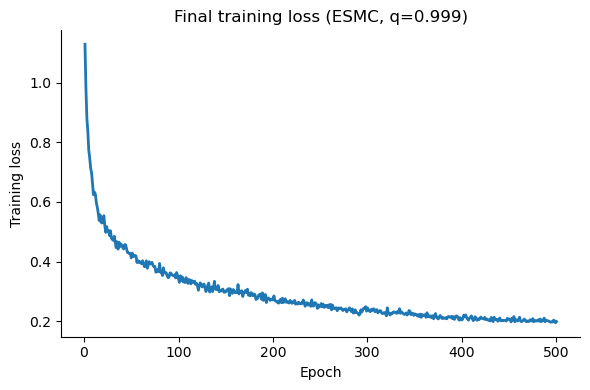

GPU cache cleared.

Training final model: ESMC, q=0.995
Host threshold: 1.000000
Final model training | host_unseen | q=0.995 | pos=1800 neg=7154 pos_weight=3.97
[FINAL q=0.995] epoch=001 loss=1.1290 lr=1.00e-03
[FINAL q=0.995] epoch=025 loss=0.5004 lr=9.94e-04
[FINAL q=0.995] epoch=050 loss=0.4125 lr=9.77e-04
[FINAL q=0.995] epoch=075 loss=0.3838 lr=9.48e-04
[FINAL q=0.995] epoch=100 loss=0.3443 lr=9.09e-04
[FINAL q=0.995] epoch=125 loss=0.3170 lr=8.61e-04
[FINAL q=0.995] epoch=150 loss=0.3009 lr=8.04e-04
[FINAL q=0.995] epoch=175 loss=0.2933 lr=7.41e-04
[FINAL q=0.995] epoch=200 loss=0.2723 lr=6.72e-04
[FINAL q=0.995] epoch=225 loss=0.2601 lr=5.99e-04
[FINAL q=0.995] epoch=250 loss=0.2538 lr=5.25e-04
[FINAL q=0.995] epoch=275 loss=0.2416 lr=4.51e-04
[FINAL q=0.995] epoch=300 loss=0.2447 lr=3.78e-04
[FINAL q=0.995] epoch=325 loss=0.2282 lr=3.09e-04
[FINAL q=0.995] epoch=350 loss=0.2263 lr=2.46e-04
[FINAL q=0.995] epoch=375 loss=0.2079 lr=1.89e-04
[FINAL q=0.995] epoch=400 loss=0.2042 

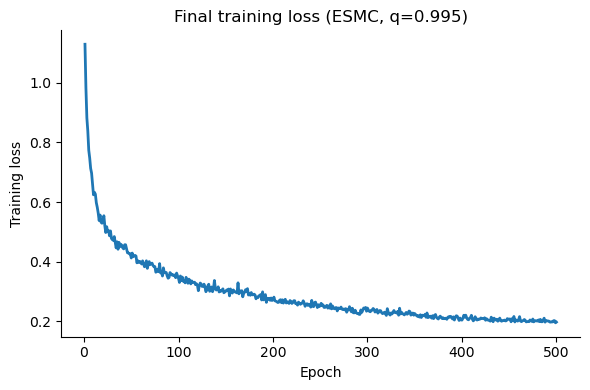

GPU cache cleared.

Training final model: ESMC, q=0.990
Host threshold: 0.999890
Final model training | host_unseen | q=0.990 | pos=1800 neg=7154 pos_weight=3.97
[FINAL q=0.990] epoch=001 loss=1.1290 lr=1.00e-03
[FINAL q=0.990] epoch=025 loss=0.5004 lr=9.94e-04
[FINAL q=0.990] epoch=050 loss=0.4126 lr=9.77e-04
[FINAL q=0.990] epoch=075 loss=0.3834 lr=9.48e-04
[FINAL q=0.990] epoch=100 loss=0.3419 lr=9.09e-04
[FINAL q=0.990] epoch=125 loss=0.3169 lr=8.61e-04
[FINAL q=0.990] epoch=150 loss=0.3002 lr=8.04e-04
[FINAL q=0.990] epoch=175 loss=0.2942 lr=7.41e-04
[FINAL q=0.990] epoch=200 loss=0.2714 lr=6.72e-04
[FINAL q=0.990] epoch=225 loss=0.2593 lr=5.99e-04
[FINAL q=0.990] epoch=250 loss=0.2532 lr=5.25e-04
[FINAL q=0.990] epoch=275 loss=0.2411 lr=4.51e-04
[FINAL q=0.990] epoch=300 loss=0.2440 lr=3.78e-04
[FINAL q=0.990] epoch=325 loss=0.2274 lr=3.09e-04
[FINAL q=0.990] epoch=350 loss=0.2252 lr=2.46e-04
[FINAL q=0.990] epoch=375 loss=0.2086 lr=1.89e-04
[FINAL q=0.990] epoch=400 loss=0.2073 

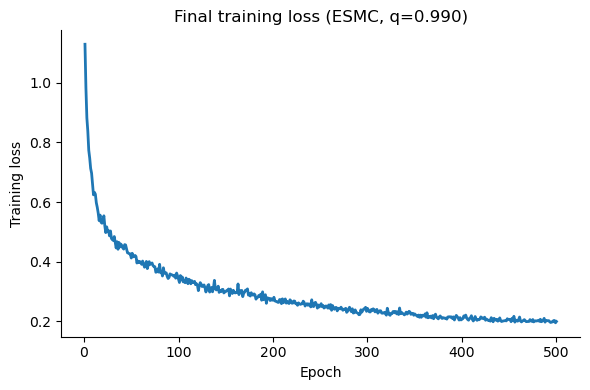

GPU cache cleared.

Training final model: ESMC, q=0.950
Host threshold: 0.992314
Final model training | host_unseen | q=0.950 | pos=1800 neg=7154 pos_weight=3.97
[FINAL q=0.950] epoch=001 loss=1.1290 lr=1.00e-03
[FINAL q=0.950] epoch=025 loss=0.5003 lr=9.94e-04
[FINAL q=0.950] epoch=050 loss=0.4127 lr=9.77e-04
[FINAL q=0.950] epoch=075 loss=0.3838 lr=9.48e-04
[FINAL q=0.950] epoch=100 loss=0.3427 lr=9.09e-04
[FINAL q=0.950] epoch=125 loss=0.3154 lr=8.61e-04
[FINAL q=0.950] epoch=150 loss=0.2996 lr=8.04e-04
[FINAL q=0.950] epoch=175 loss=0.2912 lr=7.41e-04
[FINAL q=0.950] epoch=200 loss=0.2750 lr=6.72e-04
[FINAL q=0.950] epoch=225 loss=0.2602 lr=5.99e-04
[FINAL q=0.950] epoch=250 loss=0.2540 lr=5.25e-04
[FINAL q=0.950] epoch=275 loss=0.2406 lr=4.51e-04
[FINAL q=0.950] epoch=300 loss=0.2448 lr=3.78e-04
[FINAL q=0.950] epoch=325 loss=0.2285 lr=3.09e-04
[FINAL q=0.950] epoch=350 loss=0.2243 lr=2.46e-04
[FINAL q=0.950] epoch=375 loss=0.2078 lr=1.89e-04
[FINAL q=0.950] epoch=400 loss=0.2049 

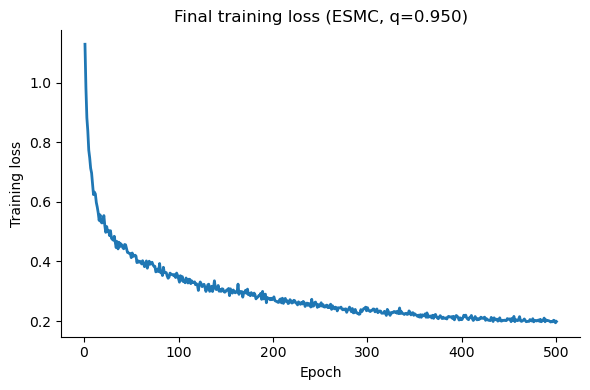

GPU cache cleared.

Training final model: ESMC, q=0.900
Host threshold: 0.922039
Final model training | host_unseen | q=0.900 | pos=1800 neg=7154 pos_weight=3.97
[FINAL q=0.900] epoch=001 loss=1.1290 lr=1.00e-03
[FINAL q=0.900] epoch=025 loss=0.5004 lr=9.94e-04
[FINAL q=0.900] epoch=050 loss=0.4130 lr=9.77e-04
[FINAL q=0.900] epoch=075 loss=0.3833 lr=9.48e-04
[FINAL q=0.900] epoch=100 loss=0.3432 lr=9.09e-04
[FINAL q=0.900] epoch=125 loss=0.3149 lr=8.61e-04
[FINAL q=0.900] epoch=150 loss=0.2984 lr=8.04e-04
[FINAL q=0.900] epoch=175 loss=0.2906 lr=7.41e-04
[FINAL q=0.900] epoch=200 loss=0.2736 lr=6.72e-04
[FINAL q=0.900] epoch=225 loss=0.2617 lr=5.99e-04
[FINAL q=0.900] epoch=250 loss=0.2521 lr=5.25e-04
[FINAL q=0.900] epoch=275 loss=0.2405 lr=4.51e-04
[FINAL q=0.900] epoch=300 loss=0.2448 lr=3.78e-04
[FINAL q=0.900] epoch=325 loss=0.2267 lr=3.09e-04
[FINAL q=0.900] epoch=350 loss=0.2246 lr=2.46e-04
[FINAL q=0.900] epoch=375 loss=0.2083 lr=1.89e-04
[FINAL q=0.900] epoch=400 loss=0.2036 

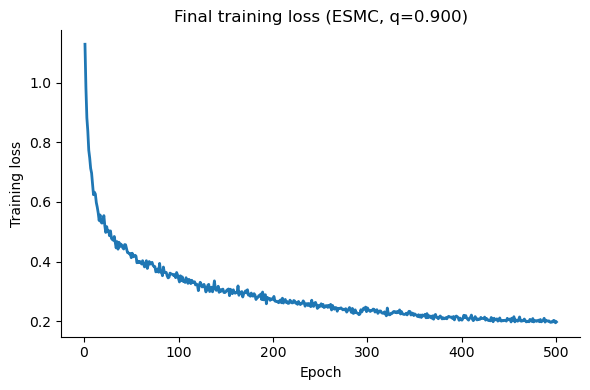

GPU cache cleared.

Training final model: ESMC, q=0.850
Host threshold: 0.883867
Final model training | host_unseen | q=0.850 | pos=1800 neg=7154 pos_weight=3.97
[FINAL q=0.850] epoch=001 loss=1.1290 lr=1.00e-03
[FINAL q=0.850] epoch=025 loss=0.5004 lr=9.94e-04
[FINAL q=0.850] epoch=050 loss=0.4123 lr=9.77e-04
[FINAL q=0.850] epoch=075 loss=0.3842 lr=9.48e-04
[FINAL q=0.850] epoch=100 loss=0.3424 lr=9.09e-04
[FINAL q=0.850] epoch=125 loss=0.3163 lr=8.61e-04
[FINAL q=0.850] epoch=150 loss=0.2989 lr=8.04e-04
[FINAL q=0.850] epoch=175 loss=0.2912 lr=7.41e-04
[FINAL q=0.850] epoch=200 loss=0.2736 lr=6.72e-04
[FINAL q=0.850] epoch=225 loss=0.2601 lr=5.99e-04
[FINAL q=0.850] epoch=250 loss=0.2532 lr=5.25e-04
[FINAL q=0.850] epoch=275 loss=0.2394 lr=4.51e-04
[FINAL q=0.850] epoch=300 loss=0.2441 lr=3.78e-04
[FINAL q=0.850] epoch=325 loss=0.2304 lr=3.09e-04
[FINAL q=0.850] epoch=350 loss=0.2243 lr=2.46e-04
[FINAL q=0.850] epoch=375 loss=0.2080 lr=1.89e-04
[FINAL q=0.850] epoch=400 loss=0.2047 

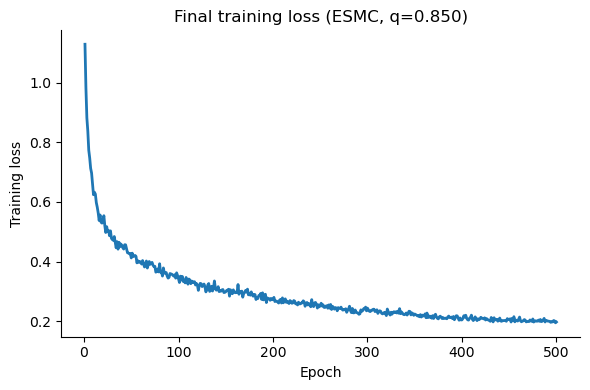

GPU cache cleared.

Training final model: ESMC, q=0.800
Host threshold: 0.807818
Final model training | host_unseen | q=0.800 | pos=1800 neg=7154 pos_weight=3.97
[FINAL q=0.800] epoch=001 loss=1.1290 lr=1.00e-03
[FINAL q=0.800] epoch=025 loss=0.5004 lr=9.94e-04
[FINAL q=0.800] epoch=050 loss=0.4122 lr=9.77e-04
[FINAL q=0.800] epoch=075 loss=0.3851 lr=9.48e-04
[FINAL q=0.800] epoch=100 loss=0.3438 lr=9.09e-04
[FINAL q=0.800] epoch=125 loss=0.3154 lr=8.61e-04
[FINAL q=0.800] epoch=150 loss=0.2994 lr=8.04e-04
[FINAL q=0.800] epoch=175 loss=0.2945 lr=7.41e-04
[FINAL q=0.800] epoch=200 loss=0.2749 lr=6.72e-04
[FINAL q=0.800] epoch=225 loss=0.2624 lr=5.99e-04
[FINAL q=0.800] epoch=250 loss=0.2531 lr=5.25e-04
[FINAL q=0.800] epoch=275 loss=0.2388 lr=4.51e-04
[FINAL q=0.800] epoch=300 loss=0.2465 lr=3.78e-04
[FINAL q=0.800] epoch=325 loss=0.2283 lr=3.09e-04
[FINAL q=0.800] epoch=350 loss=0.2237 lr=2.46e-04
[FINAL q=0.800] epoch=375 loss=0.2082 lr=1.89e-04
[FINAL q=0.800] epoch=400 loss=0.2054 

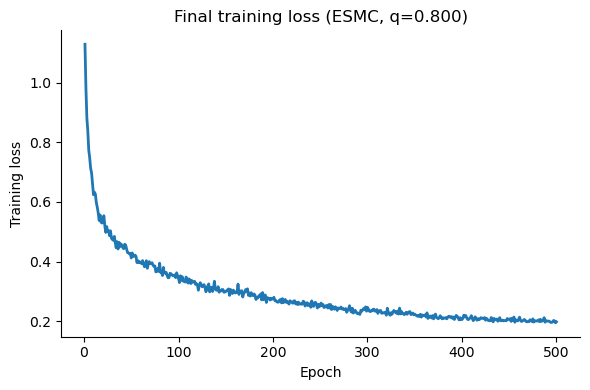

GPU cache cleared.

Training final model: ESMC, q=0.750
Host threshold: 0.761363
Final model training | host_unseen | q=0.750 | pos=1800 neg=7154 pos_weight=3.97
[FINAL q=0.750] epoch=001 loss=1.1290 lr=1.00e-03
[FINAL q=0.750] epoch=025 loss=0.5004 lr=9.94e-04
[FINAL q=0.750] epoch=050 loss=0.4129 lr=9.77e-04
[FINAL q=0.750] epoch=075 loss=0.3829 lr=9.48e-04
[FINAL q=0.750] epoch=100 loss=0.3419 lr=9.09e-04
[FINAL q=0.750] epoch=125 loss=0.3158 lr=8.61e-04
[FINAL q=0.750] epoch=150 loss=0.3027 lr=8.04e-04
[FINAL q=0.750] epoch=175 loss=0.2916 lr=7.41e-04
[FINAL q=0.750] epoch=200 loss=0.2724 lr=6.72e-04
[FINAL q=0.750] epoch=225 loss=0.2594 lr=5.99e-04
[FINAL q=0.750] epoch=250 loss=0.2540 lr=5.25e-04
[FINAL q=0.750] epoch=275 loss=0.2411 lr=4.51e-04
[FINAL q=0.750] epoch=300 loss=0.2455 lr=3.78e-04
[FINAL q=0.750] epoch=325 loss=0.2268 lr=3.09e-04
[FINAL q=0.750] epoch=350 loss=0.2255 lr=2.46e-04
[FINAL q=0.750] epoch=375 loss=0.2087 lr=1.89e-04
[FINAL q=0.750] epoch=400 loss=0.2056 

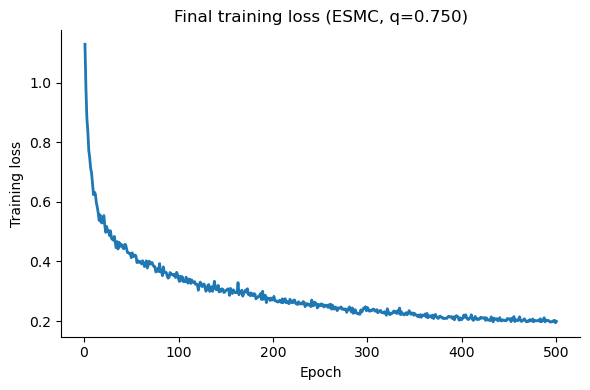

GPU cache cleared.

Final model training completed.
All models: /home/biffon/GNN_models/PhageHost_GNN/CV_training_and_results/ESMC/LOGOCV_within_type_cosineSim_outputs_PhageUnseen/FINAL_inference/models_per_q
Best model: /home/biffon/GNN_models/PhageHost_GNN/CV_training_and_results/ESMC/LOGOCV_within_type_cosineSim_outputs_PhageUnseen/FINAL_inference/models_per_q/ESMC_q_0.999_best_model
Figures: /home/biffon/GNN_models/PhageHost_GNN/CV_training_and_results/ESMC/LOGOCV_within_type_cosineSim_outputs_PhageUnseen/figures


In [34]:
# training and saving final full-data models for all similarity quantiles

FINAL_MODELS_DIR = FINAL_DIR / "models_per_q"
FINAL_MODELS_DIR.mkdir(parents=True, exist_ok=True)

for q in Q_LIST:
    q = float(q)

    folder_name = (
        f"{MODEL_NAME}_q_{q:.3f}_best_model"
        if np.isclose(q, best_q)
        else f"{MODEL_NAME}_q_{q:.3f}"
    )

    save_dir = FINAL_MODELS_DIR / folder_name
    save_dir.mkdir(parents=True, exist_ok=True)

    print("\n" + "=" * 60)
    print(f"Training final model: {MODEL_NAME}, q={q:.3f}")

    if SETTING in {"host_unseen", "both_unseen"}:
        print(f"Host threshold: {host_thr_by_q[q]:.6f}")

    if SETTING in {"phage_unseen", "both_unseen"}:
        print(f"Phage threshold: {phage_thr_by_q[q]:.6f}")

    if np.isclose(q, best_q):
        print("Best q selected by LOGOCV.")

    model_seed(SEED)

    result = train_final_model(q=q, save_dir=save_dir)
    save_final_model(result=result, q=q, save_dir=save_dir)
    cleanup_cuda()

BEST_MODEL_DIR = FINAL_MODELS_DIR / f"{MODEL_NAME}_q_{best_q:.3f}_best_model"

print("\nFinal model training completed.")
print("All models:", FINAL_MODELS_DIR.resolve())
print("Best model:", BEST_MODEL_DIR.resolve())
print("Figures:", FIG_DIR.resolve())